In [9]:
import tqdm
import numpy as np
from schwingermodel import WS_sparse_pauli_op, schwinger_kinetic_term
N = 14
thetas = np.linspace(0.0, 2, 5)
# theta = 0
# theta = 2
hams = []
for i, theta in enumerate(tqdm.tqdm(thetas)):
    H_op = WS_sparse_pauli_op(N=N, x=(N/30)**2, lam=1e3, l0=theta, m_lat=10, g=1)
    hams.append(H_op)

H_only_kinetic = schwinger_kinetic_term(N=N, x=(N/30)**2, lam=1e3, l0=theta, m_lat=10, g=1)

initial_state = '01' * (N//2)

100%|██████████| 5/5 [00:00<00:00, 216.50it/s]


In [17]:
from qiskit import QuantumCircuit
num_spins = 20

qc_state_prep = QuantumCircuit(num_spins)

for i in range(1,num_spins,2):
    qc_state_prep.x(i)

print(qc_state_prep)

           
 q_0: ─────
      ┌───┐
 q_1: ┤ X ├
      └───┘
 q_2: ─────
      ┌───┐
 q_3: ┤ X ├
      └───┘
 q_4: ─────
      ┌───┐
 q_5: ┤ X ├
      └───┘
 q_6: ─────
      ┌───┐
 q_7: ┤ X ├
      └───┘
 q_8: ─────
      ┌───┐
 q_9: ┤ X ├
      └───┘
q_10: ─────
      ┌───┐
q_11: ┤ X ├
      └───┘
q_12: ─────
      ┌───┐
q_13: ┤ X ├
      └───┘
q_14: ─────
      ┌───┐
q_15: ┤ X ├
      └───┘
q_16: ─────
      ┌───┐
q_17: ┤ X ├
      └───┘
q_18: ─────
      ┌───┐
q_19: ┤ X ├
      └───┘


In [11]:
from schwingermodel import project_hamiltonian_to_bitstring_subspace, diagonalize_projected_hamiltonian, exact_ground_state_energy

In [30]:
import random

def swap_zero_one(bs):
    """Perform one random swap between a 0 and a 1."""
    bits = list(bs)

    zero_idx = [i for i, b in enumerate(bits) if b == '0']
    one_idx  = [i for i, b in enumerate(bits) if b == '1']

    i = random.choice(zero_idx)
    j = random.choice(one_idx)

    bits[i], bits[j] = bits[j], bits[i]

    return ''.join(bits)


def grow_bitstring_list(bitstrings, N):
    """
    Add N new bitstrings by randomly picking an existing one,
    swapping a 0 and 1, and appending the result.
    """
    for _ in range(N):
        parent = random.choice(bitstrings)
        new_bs = swap_zero_one(parent)
        bitstrings.append(new_bs)

    return bitstrings

In [31]:
from BARK import BARK

In [ ]:
energies_bark = []
energies_exact = []

for ham in hams: 

    BK = BARK(ham, initial_state, max_iterations=7, time_step=0.2, tolerance=0.001, even_numbers=True)

    bases = BK.basis

    bitstrings = bases[5]
    print(len(bitstrings))
    # bitstrings = [bs for bs in bitstrings if bs.count('0') == bs.count('1')]

    grow_bitstring_list(bitstrings, 300)

    H_sub, basis = project_hamiltonian_to_bitstring_subspace(ham, bitstrings)

    evals, evecs = diagonalize_projected_hamiltonian(H_sub)

    energies_bark.append(min(evals))
    energies_exact.append(exact_ground_state_energy(ham))
    print(len(bitstrings))




Converged at iteration 4


IndexError: list index out of range

In [47]:
print(bitstrings)

['01010101010101', '01010101011010', '01010101001110', '01010101100110', '01010100110110', '01010110010110', '01010011010110', '01011001010110', '01001101010110', '01100101010110', '00110101010110', '10010101010110', '01010101010110', '01010101001011', '01010101100011', '01010100110011', '01010110010011', '01010011010011', '01011001010011', '01001101010011', '01100101010011', '00110101010011', '10010101010011', '01010101010011', '01010101101001', '01010100111001', '01010110011001', '01010011011001', '01011001011001', '01001101011001', '01100101011001', '00110101011001', '10010101011001', '01010101011001', '01010100101101', '01010110001101', '01010011001101', '01011001001101', '01001101001101', '01100101001101', '00110101001101', '10010101001101', '01010101001101', '01010110100101', '01010011100101', '01011001100101', '01001101100101', '01100101100101', '00110101100101', '10010101100101', '01010101100101', '01010010110101', '01011000110101', '01001100110101', '01100100110101', '00110100

Text(0.5, 1.0, 'Energy evolution with theta, bark vs exact')

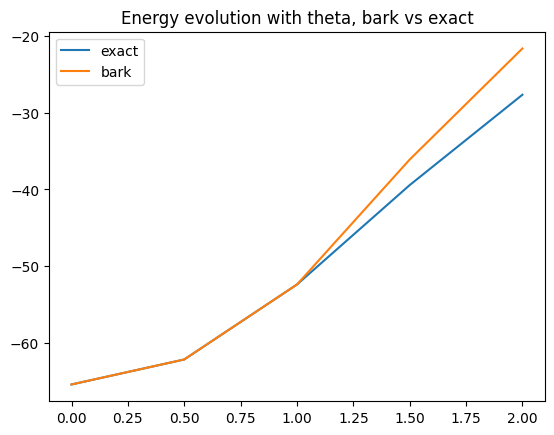

In [59]:
import matplotlib.pyplot as plt
plt.plot(thetas, energies_exact, label = 'exact')
plt.plot(thetas, energies_bark, label='bark')
plt.legend()
plt.title('Energy evolution with theta, bark vs exact')

In [7]:
bitstrings = bases[7]
print(len(bitstrings))

5812


In [8]:
H_sub, basis = project_hamiltonian_to_bitstring_subspace(H_op, bitstrings)

evals, evecs = diagonalize_projected_hamiltonian(H_sub)
print('vs. approximated via Krylov: ', min(evals))
print(f'number of bitstrings: {len(bitstrings)}')

vs. approximated via Krylov:  -16.007239874398635
number of bitstrings: 5812


In [111]:
count = 0
for bs in bitstrings: 
    if bs.count('0') != bs.count('1'): 
        count += 1

print(count)

3372


In [104]:
gs_exact = exact_ground_state_energy(H_op)
print(gs_exact)

-27.6883436545585


In [102]:
exact_energies = []
for ham in hams: 
    print('New Ham.')
    gs_exact = exact_ground_state_energy(ham)
    exact_energies.append(gs_exact)

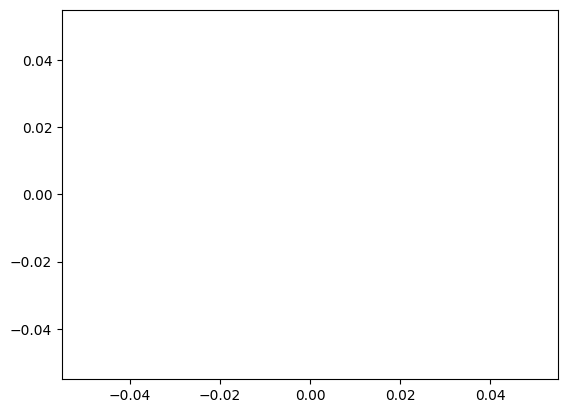

In [59]:
print(exact_energies)

[-27.68834365456961, -27.688343654563326, -27.68834365456432, -27.688343654565212, -27.688343654563322, -27.68834365456212, -27.688343654564513, -27.688343654562054, -27.68834365456097, -27.688343654563962]
